In [1]:
import cv2
import matplotlib.pyplot as plt

In [2]:
cam = cv2.VideoCapture(0)

In [3]:
rect, frame = cam.read()
cam.release()
cv2.destroyAllWindows()

In [4]:
rect

True

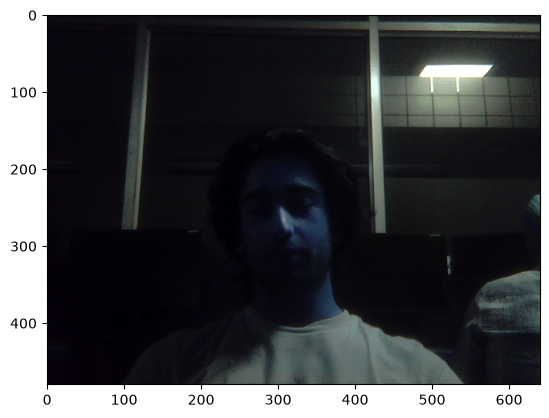

In [5]:
plt.imshow(frame)

In [6]:
cv2.namedWindow("aloo", cv2.WINDOW_NORMAL)
cam=cv2.VideoCapture(0)
while True:
    rect, frame = cam.read()
    cv2.imshow("aloo", frame)

    if cv2.waitKey(5) == ord('q'):
        break
    
cam.release()
cv2.destroyAllWindows()
    

In [9]:
import cv2

front_detector = cv2.CascadeClassifier("/home/zeus/programming/python/data/opencv/haarcascade_frontalface_default.xml")
profile_detector = cv2.CascadeClassifier("/home/zeus/programming/python/data/opencv/haarcascade_profileface.xml")

cv2.namedWindow("aloo", cv2.WINDOW_NORMAL)
cam = cv2.VideoCapture(0)

while True:
    rect, frame = cam.read()
    if not rect:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = []

    faces += list(front_detector.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=4,
        minSize=(30, 30)
    ))
    faces += list(profile_detector.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=4,
        minSize=(30, 30)
    ))

    # Remove overlaps to keep boxes cleaner
    if len(faces) > 1:
        faces = sorted(faces, key=lambda x: x[2] * x[3], reverse=True)
        keep = []
        for face in faces:
            x, y, w, h = face
            if all(not (x < kx + kw and x + w > kx and y < ky + kh and y + h > ky) for kx, ky, kw, kh in keep):
                keep.append(face)
        faces = keep

    for (x, y, w, h) in faces:
        cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 0, 255), 3)

    cv2.putText(frame, f"Faces: {len(faces)}", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    cv2.imshow("aloo", frame)
    if cv2.waitKey(5) == ord('q'):
        break

cam.release()
cv2.destroyAllWindows()
